# Generation of graph data from existing graphs

In [1]:
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import os
import pickle

## Creating a graph from the fracture network 

In [2]:
print(os.getcwd())

C:\Users\burgoaa\Desktop\python\frac_deepgen


In [3]:
# Read graphs
graphs = []
folder = 'data/shapefile'
files = sorted(f for f in os.listdir(folder) if f.endswith('.shp'))

for f_name in files:
    print(f_name)
    gdf = gpd.read_file (f'{folder}/{f_name}')
    G = nx.Graph()
    coord_to_label = {}
    precision = 5 #decimals

    for index, row in gdf.iterrows():
        line = row['geometry']
    
        if line is not None:
            coordinates = [(round(coord[0], precision), round(coord[1], precision)) for coord in line.coords]

            for i, coord in enumerate(coordinates):
                if coord not in coord_to_label:
                    label_index = len(coord_to_label)
                    coord_to_label[coord] = label_index
                    G.add_node(label_index, pos=coord)

            edges = [(coord_to_label[coordinates[i]], coord_to_label[coordinates[i + 1]]) for i in range(len(coordinates) - 1)]
            G.add_edges_from(edges)
            self_loops = list(nx.selfloop_edges(G))
            G.remove_edges_from(self_loops)
            pos = nx.get_node_attributes(G, 'pos')
    graphs.append(G)

apodi2.shp
apodi3.shp


In [4]:
import karstnet as kn
simple = []

for graph in graphs:
    # Simplify graphs with karstnet
    K = kn.from_nxGraph(graph,dict(graph.nodes('pos')), properties=dict(graph.nodes('family')), verbose=False)
    Gs = K.graph_simpl
    nx.set_node_attributes(Gs, K.pos2d, 'pos')
    simple.append(Gs)

In [33]:
largest = []
for graph in simple:
    # Identify largest 5 connected component
    all_components = list(nx.connected_components(graph))

    # Sort components by size
    components_sorted = sorted(all_components, key=len, reverse=True)

    for i, comp_nodes in enumerate(components_sorted[:10], start=1):
        # Subgraph
        Gc = graph.subgraph(comp_nodes).copy()

        if Gc.number_of_nodes() >= 30:
            largest.append(Gc)

In [34]:
def graph_area(G):
    pos = nx.get_node_attributes(G, 'pos')
    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]

    width = max(xs) - min(xs)
    height = max(ys) - min(ys)

    return width*height

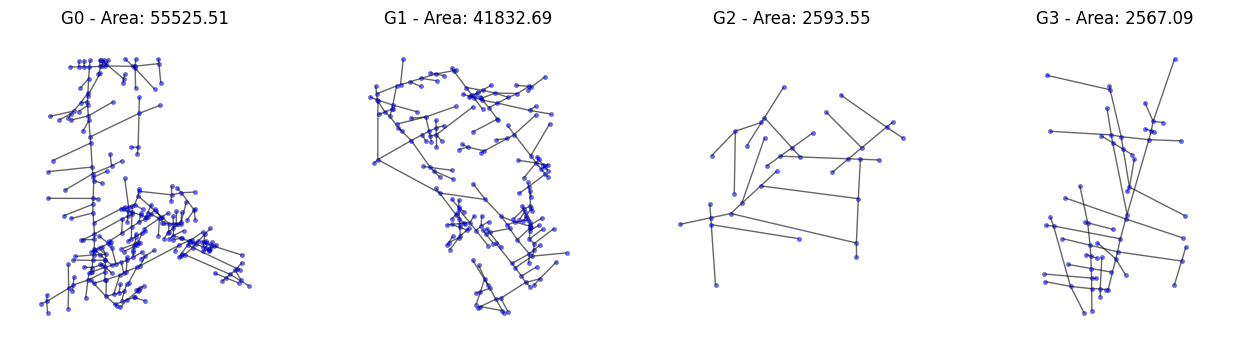

In [35]:
# Plot the fracture network as graphs
kwds = {
    'with_labels': False, 
    'node_shape': 'o',         # node symbol
    'node_color': 'blue',      # node color
    'edgecolors': 'black',     # node border color
    'node_size': 10,            # node size
    'linewidths': 0.2,         # node border width
    'edge_color': 'black',     # edge color
    'width': 1,                # edge width
    'font_size': 8,            # font size
    'font_color': 'black',      # font color
    'alpha': 0.6 ,              # transparency
}

cols = 4
rows = (len(largest) + cols -1) // cols
figsize = (4*cols, 4*rows)

fig, axes = plt.subplots(rows, cols, figsize=figsize)
axes = axes.flatten()

for i, G in enumerate(largest):
    ax = axes[i]
    plt.sca(ax)

    pos = nx.get_node_attributes(G, 'pos')

    if pos:
        nx.draw(G, pos=pos, **kwds)
        area = graph_area(G)
        ax.set_title(f'G{i} - Area: {area:.2f}')
        ax.axis('equal')
    else:
        (f'G{i} (no pos)')
        ax.axis('off')

#plt.savefig('fracgraphsTDS.png', transparent=True, dpi=300)
    
plt.show()

In [ ]:
global_efficiency(G)
estrada_index(G)
average_clustering(G)

In [44]:
import math
# Calculate lengths from graph edges
def lengths(graph):
    pos = nx.get_node_attributes(graph, 'pos')

    for u, v in graph.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        
        length = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        graph[u][v]['length'] = round(length, 3)

In [45]:
for graph in largest:
    lengths(graph)
        

In [46]:
# Calculate azimuths from graph edges
def azimuths(graph):
    pos = nx.get_node_attributes(graph, 'pos')
    for u, v in graph.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        
        # Calculate the angle between the edge and the positive y-axis
        angle_radians = math.atan2(x2 - x1, y2 - y1)
        graph[u][v]['rad'] = round(angle_radians, 2)
        
        angle_degrees = math.degrees(angle_radians)
        azimuth = (angle_degrees + 360) % 360
        graph[u][v]['azimuth'] = round(azimuth, 2)    

In [47]:
for graph in largest:
    azimuths(graph)

In [48]:
# Define sets from azimuth
def sets(azimuth):
    if (0 <= azimuth < 15) or (165 <= azimuth <= 180):
        return 'NS'
    elif 15 <= azimuth < 30:
        return 'NNE-SSW'
    elif 30 <= azimuth < 45:
        return 'NE-SW'
    elif 45 <= azimuth < 60:
        return 'NE-SW'
    elif 60 <= azimuth < 75:
        return 'ENE-WSW'
    elif 75 <= azimuth < 90:
        return 'E-W'
    elif 90 <= azimuth < 105:
        return 'E-W'
    elif 105 <= azimuth < 120:
        return 'ESE-WNW'
    elif 120 <= azimuth < 135:
        return 'SE-NW'
    elif 135 <= azimuth < 150:
        return 'SE-NWW'
    elif 150 <= azimuth < 165:
        return 'SSE-NNW'
    else:
        return 'Undefined'

In [49]:
# Assign family labels to edges based on the set definition
for graph in largest:
    for u, v, data in graph.edges(data=True):
        azimuth = data['azimuth']
        if azimuth > 180:
            azimuth = azimuth -180
        family = sets(azimuth)
        data['family'] = family

In [50]:
#Export graph as pickle with attributes
for i, graph in enumerate(largest):
    output = f'data/tds/G{i}.pickle'
    with open (output, 'wb') as f:
        pickle.dump(graph, f)